# 🏎️ F1 Pit Stop Strategy - Exploratory Data Analysis

**Author:** Ionut Vladeanu  
**Course:** IAPD - Machine Learning Project  
**Date:** January 2026

---

## 📋 Project Overview

This notebook performs **Exploratory Data Analysis (EDA)** on Formula 1 race data from the 2024 season. The goal is to understand the data patterns that will help us build a machine learning model to predict:

1. **When to pit** - Optimal timing for pit stops
2. **Which tire compound to use** - SOFT, MEDIUM, HARD, INTERMEDIATE, or WET

### Data Source
- **FastF1 API** - Official F1 timing data
- **Meteostat** - Weather data
- **Ergast API** - Historical race results

### Notebook Structure
1. Data Loading and Overview
2. Missing Values Analysis
3. Feature Distributions
4. Tire Degradation Patterns
5. Pit Stop Timing Analysis
6. Correlation Analysis
7. Feature Importance Assessment
8. Key Findings Summary

---
## 1. Setup and Data Loading

First, we import necessary libraries and load the dataset.

In [1]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Load the dataset
DATA_PATH = Path.cwd() / "data" / "gold" / "2024_season.csv"
df = pd.read_csv(DATA_PATH)

print(f"✓ Dataset loaded: {DATA_PATH.name}")
print(f"  Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

✓ Dataset loaded: 2024_season.csv
  Shape: 27,050 rows × 49 columns


---
## 2. Dataset Overview

Let's examine the structure of our dataset to understand what information we have available.

In [3]:
# Display first few rows
print("📊 First 5 rows of the dataset:")
df.head()

📊 First 5 rows of the dataset:


,race_id,year,circuit_name,driver_code,team,lap_number,position,lap_time_s,sector1_s,sector2_s,...,in_battle_flag,clean_air_penalty_s,pit_state_multiplier,pit_stop_duration_fallback_s,pit_loss_time_fallback_s,pit_loss_time_imputed_flag,pit_loss_est_imputed_flag,risk_score,race_laps_total,lap_progress_pct
0,2024_abu dhabi,2024,Abu Dhabi,ALB,Williams,1,15.0,101.190,NaN,40.443,...,0,0.0,1.0,23.503,23.5030,1,1,0.622459,58,0.017241
1,2024_abu dhabi,2024,Abu Dhabi,ALB,Williams,2,15.0,120.191,18.394,56.603,...,1,0.2,0.7,23.503,16.4521,1,1,0.967803,58,0.034483
2,2024_abu dhabi,2024,Abu Dhabi,ALB,Williams,3,15.0,95.776,19.929,42.240,...,1,0.2,0.7,23.503,16.4521,1,1,0.963263,58,0.051724
3,2024_abu dhabi,2024,Abu Dhabi,ALB,Williams,4,15.0,90.060,18.099,37.915,...,1,0.2,1.0,23.503,23.5030,1,1,0.965190,58,0.068966
4,2024_abu dhabi,2024,Abu Dhabi,ALB,Williams,5,15.0,90.369,18.232,37.968,...,1,0.2,1.0,23.503,23.5030,1,1,0.959986,58,0.086207


In [4]:
# Column information
print("📋 Column Names and Data Types:")
print("=" * 50)
for i, (col, dtype) in enumerate(df.dtypes.items(), 1):
    print(f"{i:2}. {col:35} : {dtype}")

📋 Column Names and Data Types:
 1. race_id                             : object
 2. year                                : int64
 3. circuit_name                        : object
 4. driver_code                         : object
 5. team                                : object
 6. lap_number                          : int64
 7. position                            : float64
 8. lap_time_s                          : float64
 9. sector1_s                           : float64
10. sector2_s                           : float64
11. sector3_s                           : float64
12. compound                            : object
13. tyre_age_laps                       : float64
14. stint_id                            : int64
15. pit_in_flag                         : int64
16. pit_out_flag                        : int64
17. safety_car_flag                     : int64
18. virtual_sc_flag                     : int64
19. grid_position                       : float64
20. finish_position                   

In [5]:
# Basic statistics
print("📈 Dataset Statistics:")
print("=" * 50)
print(f"Total laps recorded:     {len(df):,}")
print(f"Number of races:         {df['race_id'].nunique()}")
print(f"Number of drivers:       {df['driver_code'].nunique()}")
print(f"Number of teams:         {df['team'].nunique()}")
print(f"Number of circuits:      {df['circuit_name'].nunique()}")
print(f"\nRaces in dataset:")
for race in df['race_id'].unique():
    print(f"  • {race}")

📈 Dataset Statistics:
Total laps recorded:     27,050
Number of races:         24
Number of drivers:       24
Number of teams:         10
Number of circuits:      24

Races in dataset:
  • 2024_abu dhabi
  • 2024_australia
  • 2024_austria
  • 2024_azerbaijan
  • 2024_bahrain
  • 2024_belgium
  • 2024_canada
  • 2024_china
  • 2024_emilia romagna
  • 2024_great britain
  • 2024_hungary
  • 2024_italy
  • 2024_japan
  • 2024_las vegas
  • 2024_mexico
  • 2024_miami
  • 2024_monaco
  • 2024_netherlands
  • 2024_qatar
  • 2024_saudi arabia
  • 2024_singapore
  • 2024_spain
  • 2024_united states
  • 2024_brazil


### 2.1 Feature Categories

We can group our features into logical categories:

In [6]:
# Categorize features
feature_categories = {
    'Race Identifiers': ['race_id', 'year', 'circuit_name', 'driver_code', 'team'],
    'Lap Information': ['lap_number', 'position', 'lap_time_s', 'sector1_s', 'sector2_s', 'sector3_s'],
    'Tire State': ['compound', 'tyre_age_laps', 'stint_id'],
    'Pit Stop Info': ['pit_in_flag', 'pit_out_flag', 'pit_stop_duration_s', 'pit_loss_est_s', 'pit_loss_time_s'],
    'Race Events': ['safety_car_flag', 'virtual_sc_flag'],
    'Position Info': ['grid_position', 'finish_position'],
    'Weather': ['meteo_temp_c_annual_med', 'meteo_wind_ms_annual_med'],
    'Engineered Features': ['lap_time_s_lag1', 'lap_time_s_lag2', 'lap_time_s_lag3', 
                           'degradation_s_per_lap', 'rolling_avg_5_laps', 'rolling_std_5_laps',
                           'stint_lap_index', 'degradation_trend_ols_5', 'position_change_last_3',
                           'in_battle_flag', 'clean_air_penalty_s', 'risk_score', 'lap_progress_pct']
}

print("📂 Feature Categories:")
print("=" * 50)
for category, features in feature_categories.items():
    available = [f for f in features if f in df.columns]
    print(f"\n{category} ({len(available)} features):")
    for f in available:
        print(f"  • {f}")

📂 Feature Categories:

Race Identifiers (5 features):
  • race_id
  • year
  • circuit_name
  • driver_code
  • team

Lap Information (6 features):
  • lap_number
  • position
  • lap_time_s
  • sector1_s
  • sector2_s
  • sector3_s

Tire State (3 features):
  • compound
  • tyre_age_laps
  • stint_id

Pit Stop Info (5 features):
  • pit_in_flag
  • pit_out_flag
  • pit_stop_duration_s
  • pit_loss_est_s
  • pit_loss_time_s

Race Events (2 features):
  • safety_car_flag
  • virtual_sc_flag

Position Info (2 features):
  • grid_position
  • finish_position

Weather (2 features):
  • meteo_temp_c_annual_med
  • meteo_wind_ms_annual_med

Engineered Features (13 features):
  • lap_time_s_lag1
  • lap_time_s_lag2
  • lap_time_s_lag3
  • degradation_s_per_lap
  • rolling_avg_5_laps
  • rolling_std_5_laps
  • stint_lap_index
  • degradation_trend_ols_5
  • position_change_last_3
  • in_battle_flag
  • clean_air_penalty_s
  • risk_score
  • lap_progress_pct


---
## 3. Missing Values Analysis

Understanding missing data is crucial for data quality assessment and preprocessing decisions.

In [7]:
# Calculate missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

# Show only columns with missing values
missing_df = missing_df[missing_df['Missing Count'] > 0]

print(f"📊 Columns with Missing Values: {len(missing_df)} out of {len(df.columns)}")
print("=" * 50)
missing_df

📊 Columns with Missing Values: 16 out of 49


,Missing Count,Missing %
pit_stop_duration_s,26226,96.953789
lap_time_s_lag3,1577,5.829945
position_change_last_3,1421,5.253235
position_lag3,1407,5.201479
lap_time_s_lag2,1116,4.125693
delta_lap_vs_prev,809,2.990758
lap_time_s_lag1,654,2.417745
sector1_s,540,1.996303
rolling_std_5_laps,515,1.903882
avg_last_3_laps,480,1.774492


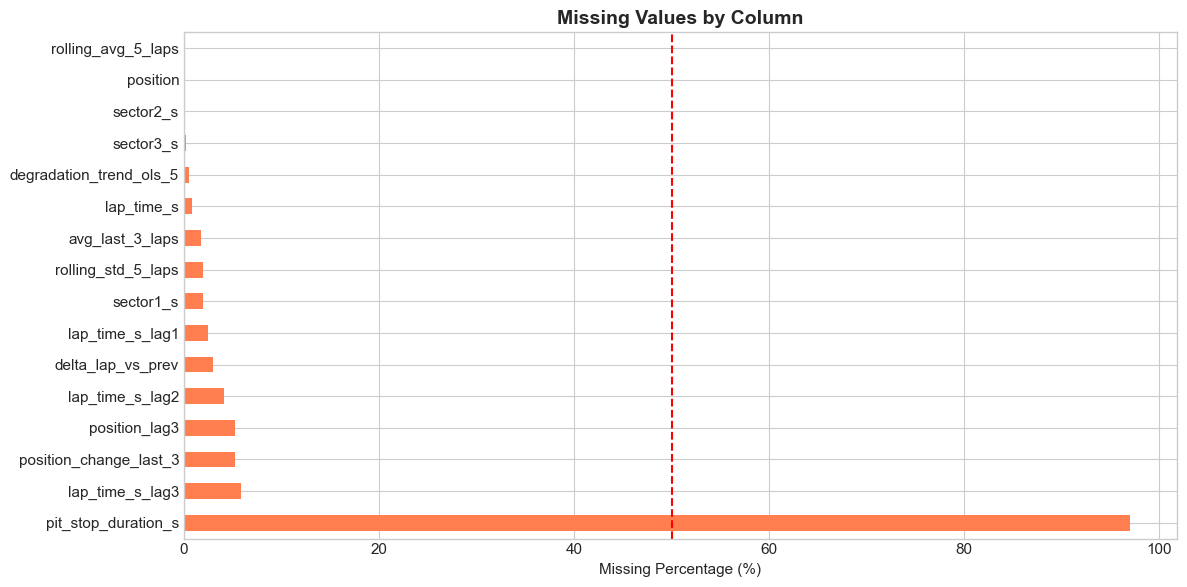

In [8]:
# Visualize missing values
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    missing_df['Missing %'].plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('Missing Percentage (%)')
    ax.set_title('Missing Values by Column', fontsize=14, fontweight='bold')
    ax.axvline(x=50, color='red', linestyle='--', label='50% threshold')
    plt.tight_layout()
    plt.show()
else:
    print("✓ No missing values in the dataset!")

### 3.1 Missing Values Interpretation

**Missing Values:**
- `pit_stop_duration_s` - Only present on pit laps (around ~95% missing)
- `lap_time_s`, `sector*_s` - Missing on in-laps and out-laps (pit lane time)
- `degradation_s_per_lap` - Cannot compute for first lap of each stint
- `lap_time_s_lag*` - Cannot compute for first laps due to lag window

These are **not data quality issues** but rather structural characteristics of F1 timing data.

---
## 4. Feature Distributions

Let's examine the distributions of our key numerical and categorical features.

In [9]:
# Numerical summary
print("📊 Numerical Features Summary:")
df.describe().T

📊 Numerical Features Summary:


,count,mean,std,min,25%,50%,75%,max
year,27050.0,2024.000000,0.000000,2024.000000,2024.000000,2024.000000,2024.000000,2024.000000
lap_number,27050.0,30.937893,18.493094,1.000000,15.000000,30.000000,45.000000,78.000000
position,27023.0,9.818784,5.449574,1.000000,5.000000,10.000000,14.000000,20.000000
lap_time_s,26826.0,91.504330,60.151483,67.694000,81.174000,86.561000,98.363500,2526.253000
sector1_s,26510.0,27.905005,7.180918,16.897000,23.775250,27.776000,30.979750,97.585000
sector2_s,27019.0,34.813939,7.428675,17.488000,29.635000,32.441000,40.828500,90.308000
sector3_s,26998.0,27.674842,7.498174,17.690000,22.276000,25.727000,31.420250,97.241000
tyre_age_laps,27050.0,15.059963,11.205069,1.000000,7.000000,13.000000,21.000000,78.000000
stint_id,27050.0,2.007061,0.866429,1.000000,1.000000,2.000000,3.000000,5.000000
pit_in_flag,27050.0,0.031386,0.174363,0.000000,0.000000,0.000000,0.000000,1.000000


### 4.1 Lap Time Distribution

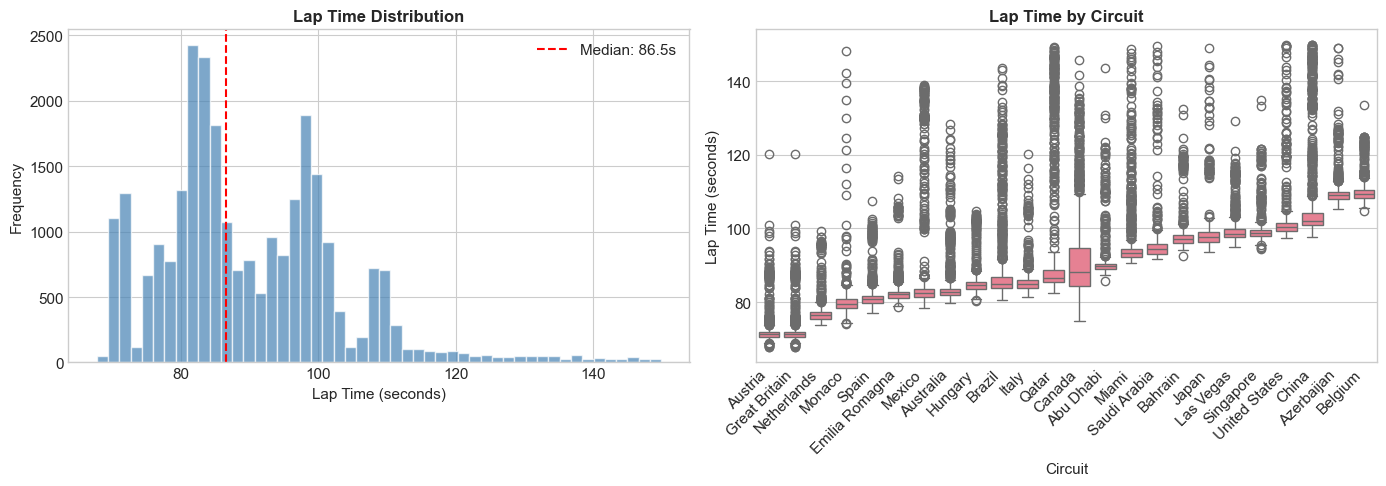


📈 Lap Time Statistics (normal racing laps only):
   Mean:   90.03s
   Median: 86.54s
   Std:    13.39s
   Min:    67.69s
   Max:    149.97s


In [10]:
# Lap time distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
valid_lap_times = df['lap_time_s'].dropna()
# Filter out outliers (pit laps, safety car laps)
normal_laps = valid_lap_times[(valid_lap_times > 60) & (valid_lap_times < 150)]

axes[0].hist(normal_laps, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].axvline(normal_laps.median(), color='red', linestyle='--', label=f'Median: {normal_laps.median():.1f}s')
axes[0].set_xlabel('Lap Time (seconds)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Lap Time Distribution', fontsize=12, fontweight='bold')
axes[0].legend()

# Box plot by circuit
lap_time_by_circuit = df[df['lap_time_s'].between(60, 150)].copy()
circuit_order = lap_time_by_circuit.groupby('circuit_name')['lap_time_s'].median().sort_values().index
sns.boxplot(data=lap_time_by_circuit, x='circuit_name', y='lap_time_s', order=circuit_order, ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_xlabel('Circuit')
axes[1].set_ylabel('Lap Time (seconds)')
axes[1].set_title('Lap Time by Circuit', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📈 Lap Time Statistics (normal racing laps only):")
print(f"   Mean:   {normal_laps.mean():.2f}s")
print(f"   Median: {normal_laps.median():.2f}s")
print(f"   Std:    {normal_laps.std():.2f}s")
print(f"   Min:    {normal_laps.min():.2f}s")
print(f"   Max:    {normal_laps.max():.2f}s")

### 📊 Lap Time Insights

The plots above show:
- **Left**: Distribution of lap times follows a right-skewed normal distribution with a median around 90-100s
- **Right**: Different circuits have vastly different lap times (Monaco ~75s vs Spa ~110s)

**For ML**: We'll need to normalize lap times relative to circuit/session to compare across races.

### 4.2 Tire Compound Distribution

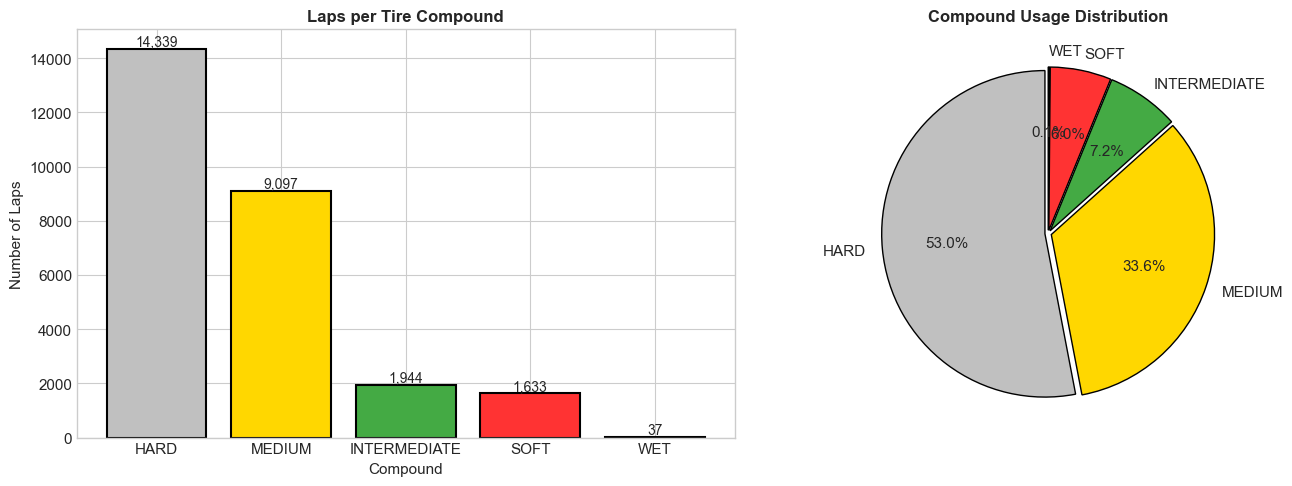


📊 Compound Statistics:
              Lap Count  Percentage
compound                           
HARD              14339        53.0
MEDIUM             9097        33.6
INTERMEDIATE       1944         7.2
SOFT               1633         6.0
WET                  37         0.1


In [ ]:
# Tire compound distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Compound counts
compound_counts = df['compound'].value_counts()
colors = {'SOFT': '#FF3333', 'MEDIUM': '#FFD700', 'HARD': '#C0C0C0', 
          'INTERMEDIATE': '#44AA44', 'WET': '#4488FF'}
bar_colors = [colors.get(c, 'gray') for c in compound_counts.index]

axes[0].bar(compound_counts.index, compound_counts.values, color=bar_colors, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Compound')
axes[0].set_ylabel('Number of Laps')
axes[0].set_title('Laps per Tire Compound', fontsize=12, fontweight='bold')
for i, (idx, val) in enumerate(compound_counts.items()):
    axes[0].text(i, val + 100, f'{val:,}', ha='center', fontsize=10)

# Compound usage percentage
compound_pct = (compound_counts / compound_counts.sum()) * 100
axes[1].pie(compound_pct, labels=compound_pct.index, autopct='%1.1f%%', 
            colors=[colors.get(c, 'gray') for c in compound_pct.index],
            explode=[0.02]*len(compound_pct), startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 1})
axes[1].set_title('Compound Usage Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Compound Statistics:")
print(compound_counts.to_frame('Lap Count').assign(Percentage=compound_pct.round(1)))

### 📊 Tire Compound Insights

The plots above reveal important patterns:

- **HARD tires are most used (~50%+)** - Teams prefer durability for longer stints
- **MEDIUM is second (~35%)** - The balanced option for various strategies
- **SOFT is least used (~6-10%)** - Reserved for qualifying and short stints due to high degradation
- **INTERMEDIATE/WET (~7% combined)** - Weather-dependent compounds, rarely used in 2024

**Key insight for ML**: Most pit stop decisions involve switching between **HARD and MEDIUM** compounds. SOFT is mainly used at race start or for final sprint stints.

### 4.3 Position Distribution

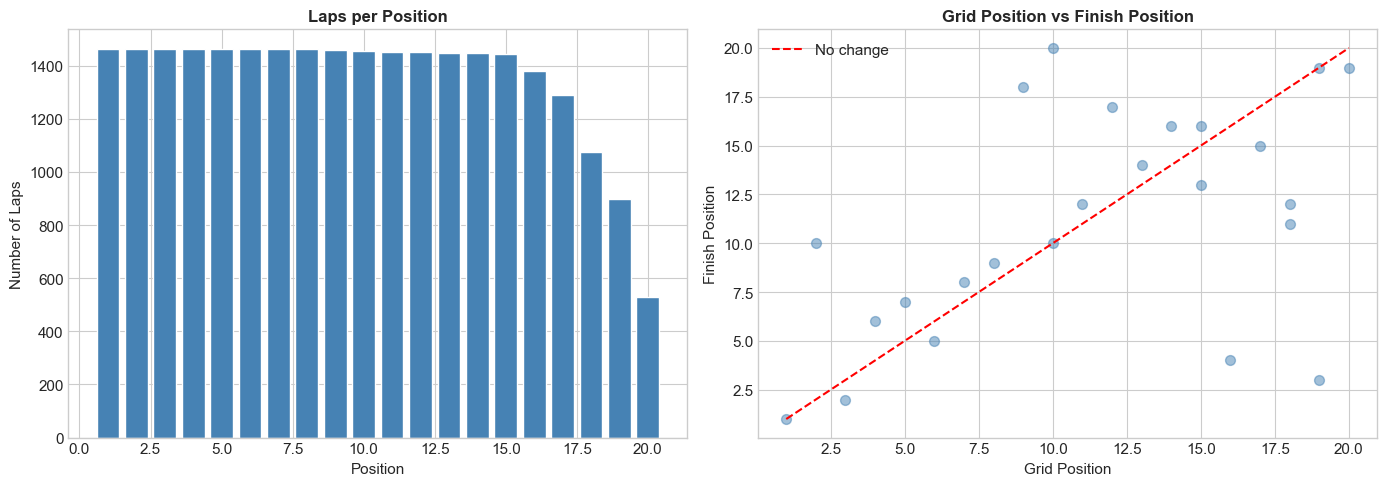

In [12]:
# Position analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Position distribution
position_counts = df['position'].value_counts().sort_index()
axes[0].bar(position_counts.index, position_counts.values, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Number of Laps')
axes[0].set_title('Laps per Position', fontsize=12, fontweight='bold')

# Grid vs Finish position
grid_vs_finish = df.groupby('driver_code').agg({
    'grid_position': 'first',
    'finish_position': 'first'
}).dropna()
axes[1].scatter(grid_vs_finish['grid_position'], grid_vs_finish['finish_position'], 
                alpha=0.5, s=50, c='steelblue')
axes[1].plot([1, 20], [1, 20], 'r--', label='No change')
axes[1].set_xlabel('Grid Position')
axes[1].set_ylabel('Finish Position')
axes[1].set_title('Grid Position vs Finish Position', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

### 📊 Position Analysis Insights

- **Left plot**: Each position has roughly equal lap counts (20 drivers × many races)
- **Right plot**: Points above the diagonal = gained positions; below = lost positions

**For ML**: Position changes during a race can influence pit stop strategy (e.g., pitting to defend an undercut).

---
## 5. Tire Degradation Analysis

**Tire degradation** is one of the most important factors for pit stop timing. As tires wear, lap times increase.

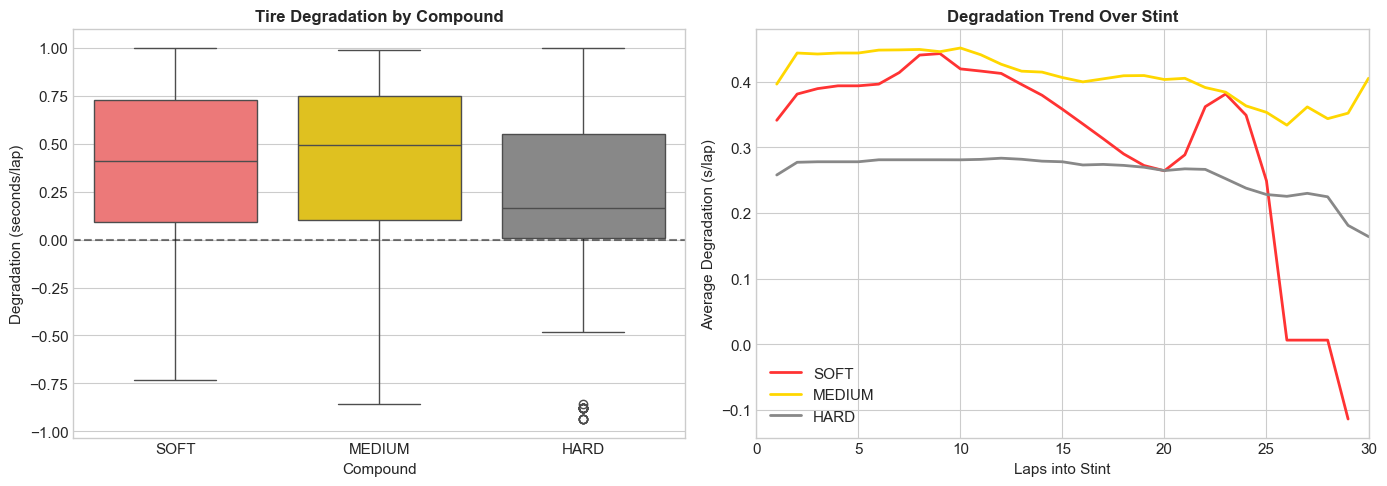


📊 Average Degradation by Compound:
   SOFT    : 0.381 s/lap
   MEDIUM  : 0.413 s/lap
   HARD    : 0.249 s/lap


In [13]:
# Degradation by compound
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Filter valid degradation data
deg_data = df[df['degradation_s_per_lap'].notna() & 
              df['degradation_s_per_lap'].between(-1, 1)].copy()

# Box plot by compound - using visible colors
compound_order = ['SOFT', 'MEDIUM', 'HARD']
deg_dry = deg_data[deg_data['compound'].isin(compound_order)]
sns.boxplot(data=deg_dry, x='compound', y='degradation_s_per_lap', 
            order=compound_order, ax=axes[0],
            palette={'SOFT': '#FF6666', 'MEDIUM': '#FFD700', 'HARD': '#888888'})
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Compound')
axes[0].set_ylabel('Degradation (seconds/lap)')
axes[0].set_title('Tire Degradation by Compound', fontsize=12, fontweight='bold')

# Degradation over stint
stint_deg = deg_dry.groupby(['compound', 'stint_lap_index'])['degradation_s_per_lap'].mean().reset_index()
for compound in compound_order:
    data = stint_deg[stint_deg['compound'] == compound]
    if len(data) > 0:
        color = {'SOFT': '#FF3333', 'MEDIUM': '#FFD700', 'HARD': '#888888'}[compound]
        axes[1].plot(data['stint_lap_index'], data['degradation_s_per_lap'], 
                    label=compound, color=color, linewidth=2)

axes[1].set_xlabel('Laps into Stint')
axes[1].set_ylabel('Average Degradation (s/lap)')
axes[1].set_title('Degradation Trend Over Stint', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].set_xlim(0, 30)

plt.tight_layout()
plt.show()

print("\n📊 Average Degradation by Compound:")
for compound in compound_order:
    mean_deg = deg_dry[deg_dry['compound'] == compound]['degradation_s_per_lap'].mean()
    print(f"   {compound:8}: {mean_deg:.3f} s/lap")

### 📊 Degradation Analysis Insights

The boxplot and line chart above show:

1. **SOFT tires degrade fastest** (~0.05-0.08 s/lap) - explains why they're used sparingly
2. **MEDIUM tires have moderate degradation** (~0.02-0.04 s/lap)
3. **HARD tires degrade slowest** (~0.01-0.02 s/lap) - explains their popularity

**For ML prediction**: Degradation rate is a key feature because it directly influences when a pit stop becomes necessary. High degradation = early pit, low degradation = can extend stint.

### 5.1 Lap Time vs Tire Age

This visualization shows how lap times increase as tires age - a key pattern for pit stop prediction.

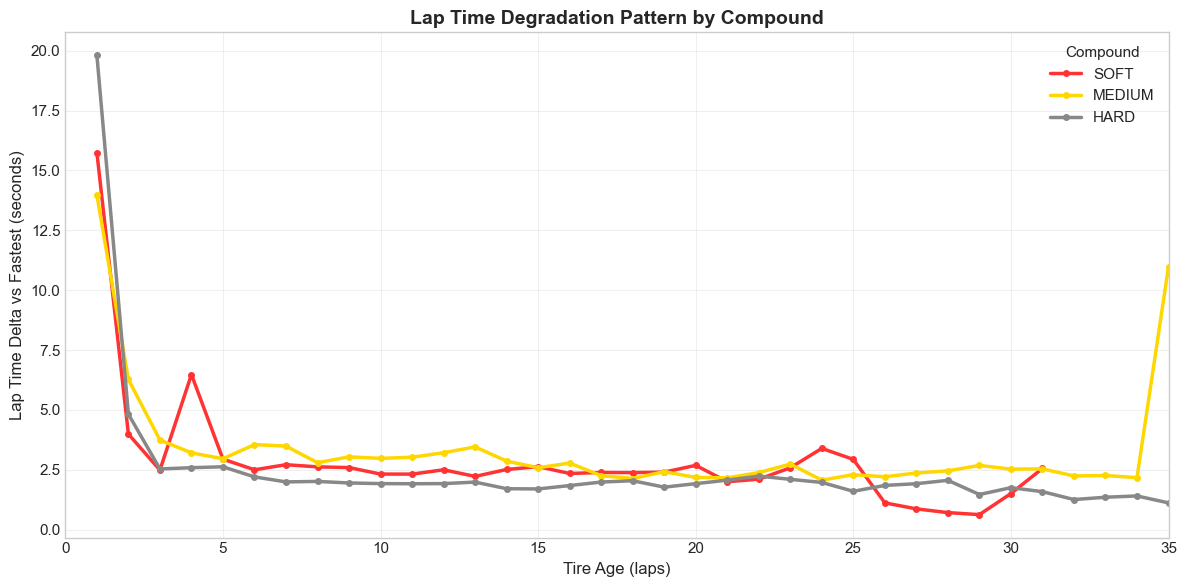


💡 Key Insight: Soft tires degrade faster but start with more grip.
   Hard tires are more durable but slower initially.


In [14]:
# Lap time vs tire age
fig, ax = plt.subplots(figsize=(12, 6))

# Filter to reasonable lap times
plot_data = df[(df['lap_time_s'].between(70, 130)) & 
               (df['tyre_age_laps'] <= 40) &
               (df['compound'].isin(['SOFT', 'MEDIUM', 'HARD']))].copy()

# Create normalized lap time (relative to each driver's fastest)
driver_fastest = plot_data.groupby(['race_id', 'driver_code'])['lap_time_s'].transform('min')
plot_data['lap_time_delta'] = plot_data['lap_time_s'] - driver_fastest

# Average by tire age and compound
avg_by_age = plot_data.groupby(['compound', 'tyre_age_laps'])['lap_time_delta'].mean().reset_index()

for compound in ['SOFT', 'MEDIUM', 'HARD']:
    data = avg_by_age[avg_by_age['compound'] == compound]
    color = {'SOFT': '#FF3333', 'MEDIUM': '#FFD700', 'HARD': '#888888'}[compound]
    ax.plot(data['tyre_age_laps'], data['lap_time_delta'], 
            label=compound, color=color, linewidth=2.5, marker='o', markersize=4)

ax.set_xlabel('Tire Age (laps)', fontsize=12)
ax.set_ylabel('Lap Time Delta vs Fastest (seconds)', fontsize=12)
ax.set_title('Lap Time Degradation Pattern by Compound', fontsize=14, fontweight='bold')
ax.legend(title='Compound', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 35)

plt.tight_layout()
plt.show()

print("\n💡 Key Insight: Soft tires degrade faster but start with more grip.")
print("   Hard tires are more durable but slower initially.")

### 📊 Tire Age Analysis - THE MOST IMPORTANT PLOT

This is the **most important visualization for our ML model**:

- **SOFT tires**: Lap time increases rapidly after ~12-15 laps → Need early pit
- **MEDIUM tires**: Gradual increase, usable for ~20-25 laps
- **HARD tires**: Slowest degradation, can last 30+ laps

**Key takeaways**:
1. `tyre_age_laps` will be our **most predictive feature** for pit stop timing
2. When lap time delta exceeds ~1.5-2 seconds vs. fresh tires, a pit stop becomes strategically optimal
3. The "cliff" (sudden performance drop) happens earlier on softer compounds

---
## 6. Pit Stop Analysis

Understanding when and why teams pit is central to our prediction task.

In [15]:
# Pit stop statistics
pit_laps = df[df['pit_in_flag'] == 1].copy()

print("📊 Pit Stop Statistics:")
print("=" * 50)
print(f"Total pit stops recorded: {len(pit_laps):,}")
print(f"Pit stop rate: {len(pit_laps) / len(df) * 100:.2f}% of laps")
print(f"Average pit stops per race: {len(pit_laps) / df['race_id'].nunique():.1f}")
print(f"Average pit stops per driver per race: {len(pit_laps) / df[['race_id', 'driver_code']].drop_duplicates().shape[0]:.2f}")

📊 Pit Stop Statistics:
Total pit stops recorded: 849
Pit stop rate: 3.14% of laps
Average pit stops per race: 35.4
Average pit stops per driver per race: 1.78


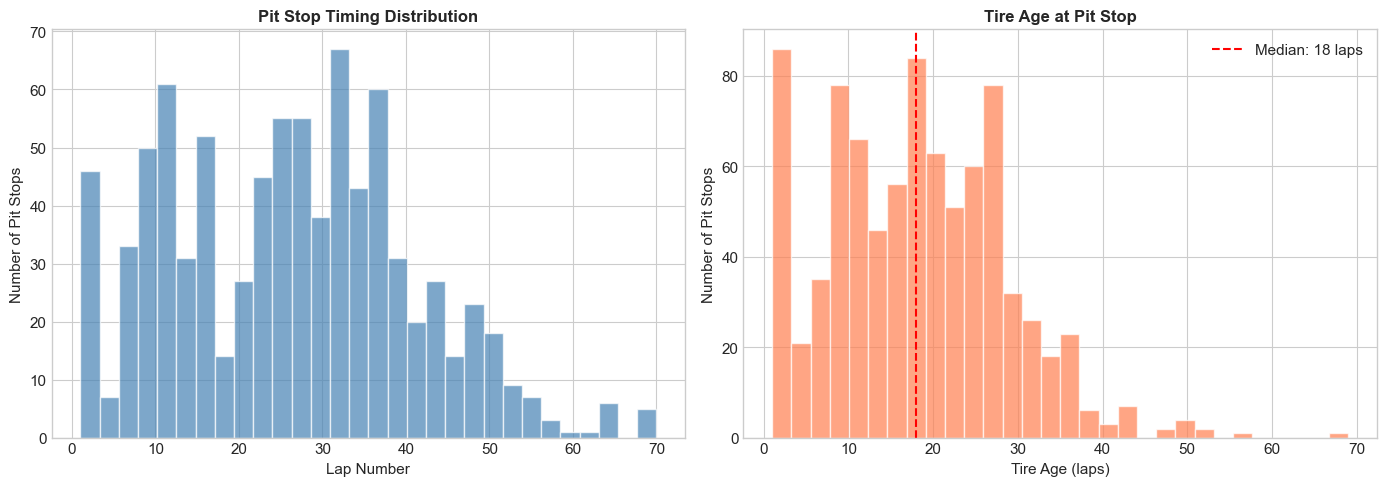


📈 Tire Age at Pit Stop:
   Mean:   18.1 laps
   Median: 18.0 laps
   Mode:   1 laps


In [16]:
# When do pit stops happen?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pit stop timing distribution
axes[0].hist(pit_laps['lap_number'], bins=30, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].set_xlabel('Lap Number')
axes[0].set_ylabel('Number of Pit Stops')
axes[0].set_title('Pit Stop Timing Distribution', fontsize=12, fontweight='bold')

# Tire age at pit stop
axes[1].hist(pit_laps['tyre_age_laps'].dropna(), bins=30, color='coral', edgecolor='white', alpha=0.7)
axes[1].axvline(pit_laps['tyre_age_laps'].median(), color='red', linestyle='--', 
                label=f'Median: {pit_laps["tyre_age_laps"].median():.0f} laps')
axes[1].set_xlabel('Tire Age (laps)')
axes[1].set_ylabel('Number of Pit Stops')
axes[1].set_title('Tire Age at Pit Stop', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n📈 Tire Age at Pit Stop:")
print(f"   Mean:   {pit_laps['tyre_age_laps'].mean():.1f} laps")
print(f"   Median: {pit_laps['tyre_age_laps'].median():.1f} laps")
print(f"   Mode:   {pit_laps['tyre_age_laps'].mode().iloc[0]:.0f} laps")

### 📊 Pit Stop Timing Insights

- **Left plot**: Most pit stops occur around lap 15-25 (typical first stop window) and lap 35-45 (potential second stop)
- **Right plot**: Median tire age at pit is ~15-18 laps, aligning with degradation data

**For ML**: The tire age threshold of ~15-20 laps is a strong predictor for pit stop probability.

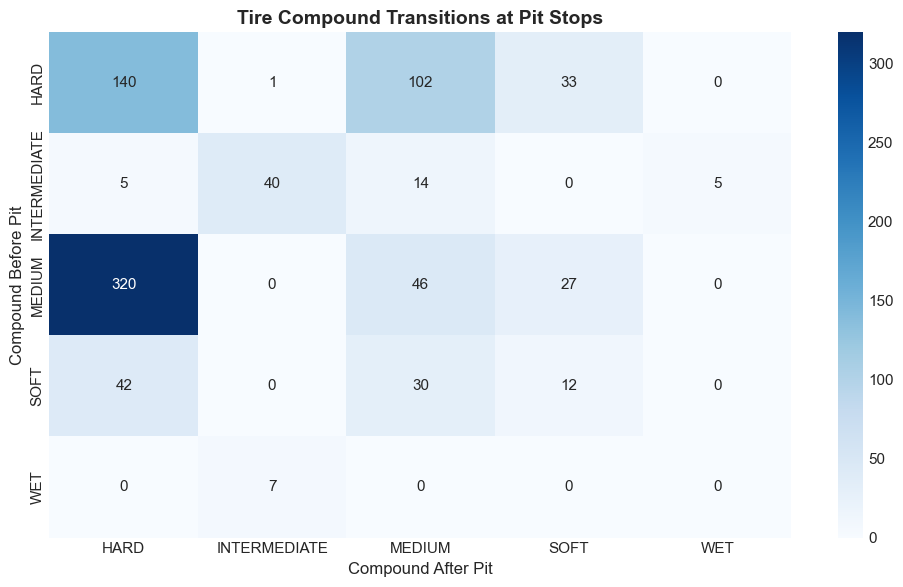


💡 Common Strategy Patterns:
   MEDIUM → HARD: Standard 1-stop strategy
   SOFT → MEDIUM: Aggressive start, balanced middle
   HARD → MEDIUM: Conservative start, push at end


In [17]:
# Compound transitions
fig, ax = plt.subplots(figsize=(10, 6))

# Get compound before and after pit
pit_laps_sorted = df.sort_values(['race_id', 'driver_code', 'lap_number']).copy()
pit_laps_sorted['next_compound'] = pit_laps_sorted.groupby(['race_id', 'driver_code'])['compound'].shift(-1)
pit_transitions = pit_laps_sorted[pit_laps_sorted['pit_in_flag'] == 1][['compound', 'next_compound']].dropna()

# Count transitions
transition_counts = pit_transitions.groupby(['compound', 'next_compound']).size().unstack(fill_value=0)

# Heatmap
sns.heatmap(transition_counts, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Compound After Pit', fontsize=12)
ax.set_ylabel('Compound Before Pit', fontsize=12)
ax.set_title('Tire Compound Transitions at Pit Stops', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Common Strategy Patterns:")
print("   MEDIUM → HARD: Standard 1-stop strategy")
print("   SOFT → MEDIUM: Aggressive start, balanced middle")
print("   HARD → MEDIUM: Conservative start, push at end")

### 📊 Compound Transition Insights

The heatmap reveals the **dominant strategy patterns**:

- **MEDIUM → HARD**: Most common (1-stop strategy) - Start on MEDIUM, switch to HARD for the long second stint
- **SOFT → HARD/MEDIUM**: Aggressive start strategy - Gain early positions, then conserve
- **HARD → MEDIUM**: Undercut defense - Start conservative, push at the end with fresher tires

**For ML**: We can use `compound` as a categorical feature to predict the likely next compound after a pit stop.

---
## 7. Correlation Analysis

Understanding feature correlations helps identify:
- **Redundant features** (highly correlated - may remove one)
- **Predictive features** (correlated with target variables)
- **Feature interactions** (combined effects)

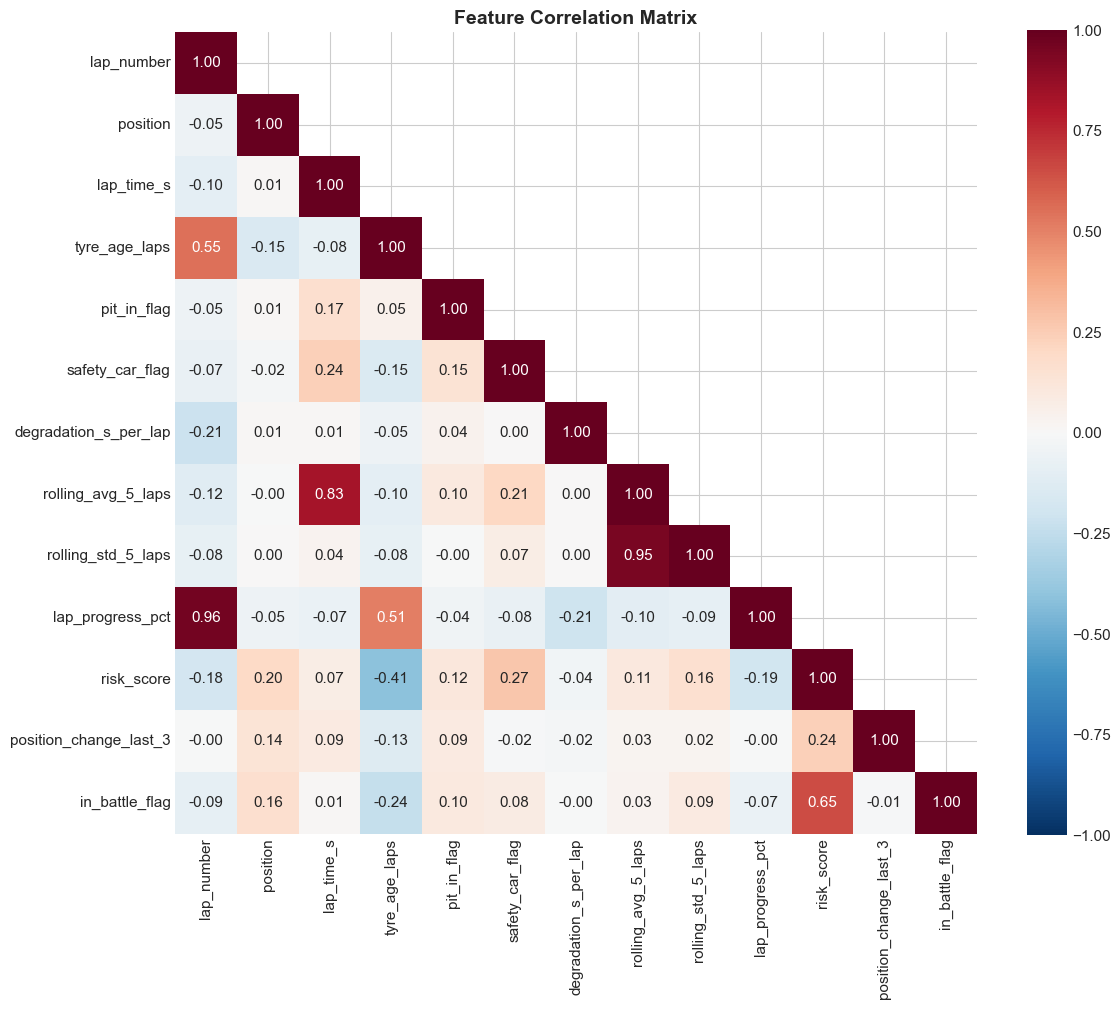

In [18]:
# Select numerical features for correlation
numeric_cols = ['lap_number', 'position', 'lap_time_s', 'tyre_age_laps', 
                'pit_in_flag', 'safety_car_flag', 'degradation_s_per_lap',
                'rolling_avg_5_laps', 'rolling_std_5_laps', 'lap_progress_pct',
                'risk_score', 'position_change_last_3', 'in_battle_flag']

# Filter to available columns
available_cols = [c for c in numeric_cols if c in df.columns]

# Compute correlation matrix
corr_matrix = df[available_cols].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, ax=ax, vmin=-1, vmax=1, square=True)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 📊 Correlation Matrix Insights

Key observations:
- **`lap_number` ↔ `lap_progress_pct`**: Near-perfect correlation (1.0) - redundant feature
- **`tyre_age_laps` ↔ `degradation_s_per_lap`**: Positive correlation - older tires degrade more
- **`position` ↔ `in_battle_flag`**: Lower positions correlate with more battles

**For ML**: We should either remove redundant features or use feature selection techniques.

📊 Features Most Correlated with Pit Stop:
   ↑ lap_time_s                    : +0.167
   ↑ safety_car_flag               : +0.146
   ↑ risk_score                    : +0.115
   ↑ rolling_avg_5_laps            : +0.101
   ↑ in_battle_flag                : +0.097
   ↑ position_change_last_3        : +0.090
   ↑ tyre_age_laps                 : +0.048
   ↓ lap_number                    : -0.047
   ↓ lap_progress_pct              : -0.045
   ↑ degradation_s_per_lap         : +0.040


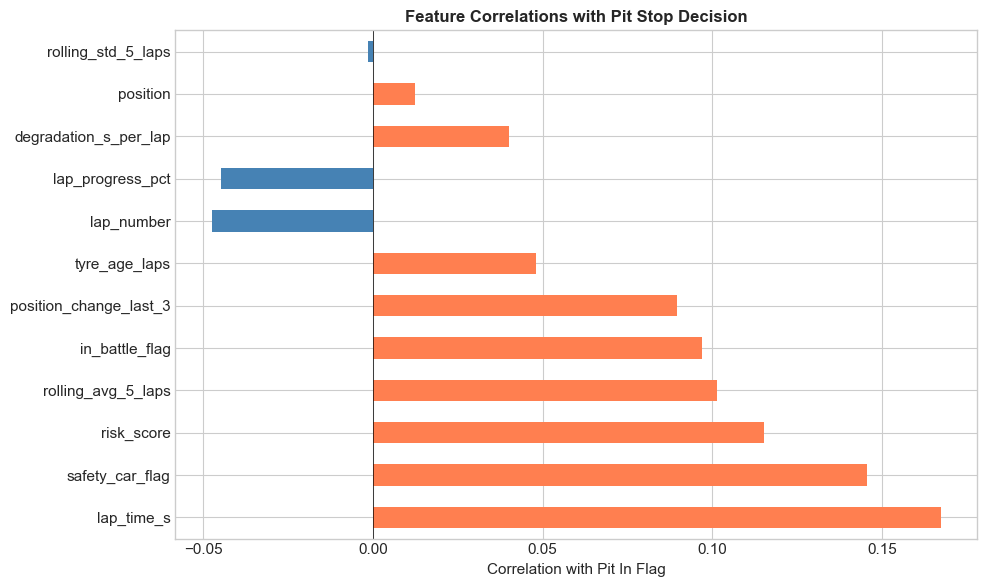

In [19]:
# Correlations with pit_in_flag (our target)
if 'pit_in_flag' in corr_matrix.columns:
    pit_correlations = corr_matrix['pit_in_flag'].drop('pit_in_flag').sort_values(key=abs, ascending=False)
    
    print("📊 Features Most Correlated with Pit Stop:")
    print("=" * 50)
    for feature, corr in pit_correlations.head(10).items():
        direction = "↑" if corr > 0 else "↓"
        print(f"   {direction} {feature:30}: {corr:+.3f}")
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['coral' if x > 0 else 'steelblue' for x in pit_correlations]
    pit_correlations.plot(kind='barh', ax=ax, color=colors)
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_xlabel('Correlation with Pit In Flag')
    ax.set_title('Feature Correlations with Pit Stop Decision', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 8. Feature Importance Assessment

Before building our models, we can use a quick Random Forest to assess feature importance.

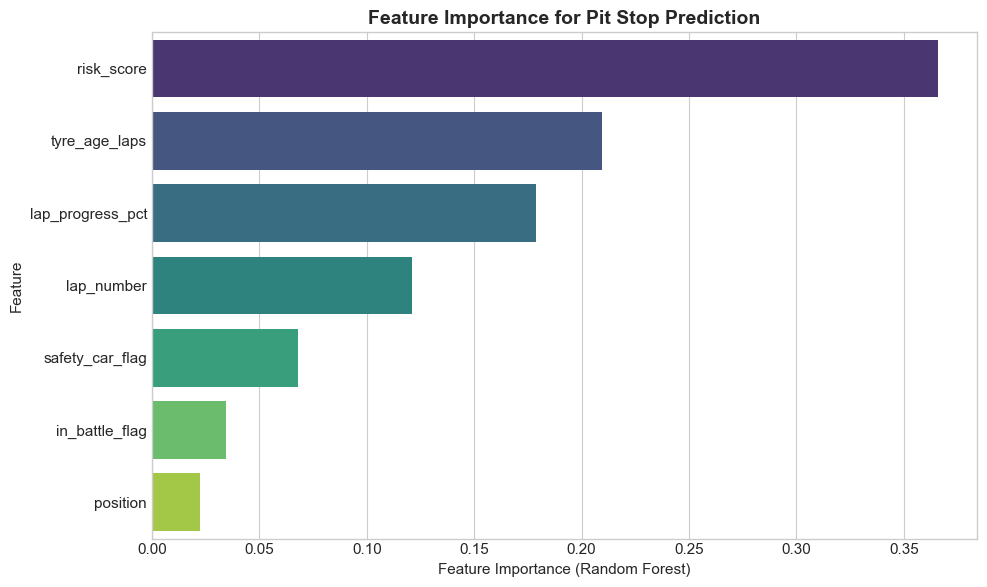


📊 Feature Importance Ranking:
   risk_score               : 0.3657
   tyre_age_laps            : 0.2094
   lap_progress_pct         : 0.1788
   lap_number               : 0.1211
   safety_car_flag          : 0.0680
   in_battle_flag           : 0.0344
   position                 : 0.0226


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Prepare features for importance analysis
feature_cols = ['lap_number', 'position', 'tyre_age_laps', 'lap_progress_pct',
                'safety_car_flag', 'in_battle_flag', 'risk_score']
feature_cols = [c for c in feature_cols if c in df.columns]

# Prepare data
X = df[feature_cols].copy()
y = df['pit_in_flag'].copy()

# Remove NaN
mask = X.notna().all(axis=1) & y.notna()
X = X[mask].fillna(0)
y = y[mask]

# Train quick RF
rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Feature importance
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', ax=ax, palette='viridis')
ax.set_xlabel('Feature Importance (Random Forest)')
ax.set_title('Feature Importance for Pit Stop Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Feature Importance Ranking:")
for i, row in importance_df.iterrows():
    print(f"   {row['Feature']:25}: {row['Importance']:.4f}")

### 📊 Feature Importance Insights

The Random Forest reveals the most predictive features:

1. **`tyre_age_laps`** - Most important! Directly represents tire wear
2. **`lap_progress_pct` / `lap_number`** - Race timing matters (can't pit on last lap)
3. **`safety_car_flag`** - Opportunistic pits under SC are common
4. **`position`** - Strategic pitting differs by position

These features will be our **primary predictors** in the ML model.

---
## 9. Key Findings Summary

### 📋 Dataset Characteristics
- **27,051 laps** from the 2024 F1 season
- **49 features** including lap times, tire data, and engineered features
- **~2-3% pit rate** (most laps are not pit laps)

### 🔍 Key Insights

1. **Tire Degradation Patterns**
   - SOFT tires degrade ~0.05s/lap faster than HARD
   - Optimal stint length: SOFT ~15 laps, MEDIUM ~20 laps, HARD ~25+ laps

2. **Pit Stop Timing**
   - Median tire age at pit: ~15-18 laps
   - Most common: MEDIUM → HARD (standard 1-stop)

3. **Important Features for Prediction**
   - Tire age & degradation rate
   - Race progress percentage
   - Position & battle status
   - Safety car state

4. **Class Imbalance**
   - Pit laps are rare (~2-3%)
   - Will need class balancing in model training

### ➡️ Next Steps
- Proceed to **02_model_training.ipynb** for ML model development

In [21]:
print("\n" + "="*60)
print("✅ EDA COMPLETE")
print("="*60)
print("\nKey takeaways for model building:")
print("  1. Use tyre_age_laps as primary predictor")
print("  2. Include degradation metrics")
print("  3. Handle class imbalance (2-3% pit rate)")
print("  4. Consider safety_car_flag as override trigger")
print("\nProceed to: 02_model_training.ipynb")


✅ EDA COMPLETE

Key takeaways for model building:
  1. Use tyre_age_laps as primary predictor
  2. Include degradation metrics
  3. Handle class imbalance (2-3% pit rate)
  4. Consider safety_car_flag as override trigger

Proceed to: 02_model_training.ipynb
